In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
trace_num = 2000
order = '3'
opt = 'o3' # o0 or o3
scope = '' # _chipwhisperer or space
algo = 'PQClean' # orgPoly or PQClean or pqm4
platform = 'CW308_STM32F4' # CW308_STM32F3 or CW308_STM32F4 or CWLITEARM

trace_path = f'traces{scope}/{trace_num}/traces_unfixed_message_{trace_num}_{platform}_{opt}_{algo}_{order}'

t = np.load(f'{trace_path}/trace.npy')
m = np.load(f'{trace_path}/message.npy')

In [3]:
print(t.shape)
print(m.shape)
print(m)

(2000, 455000)
(2000, 32)
[[116. 224.  11. ...   5. 141.  26.]
 [252.   7. 243. ...  58.  26.  43.]
 [ 22.  73.   3. ... 166.  16. 124.]
 ...
 [101.  94. 126. ... 250.  70.  99.]
 [  4.  99. 150. ... 140. 211. 153.]
 [211. 254. 103. ...  72. 192.  66.]]


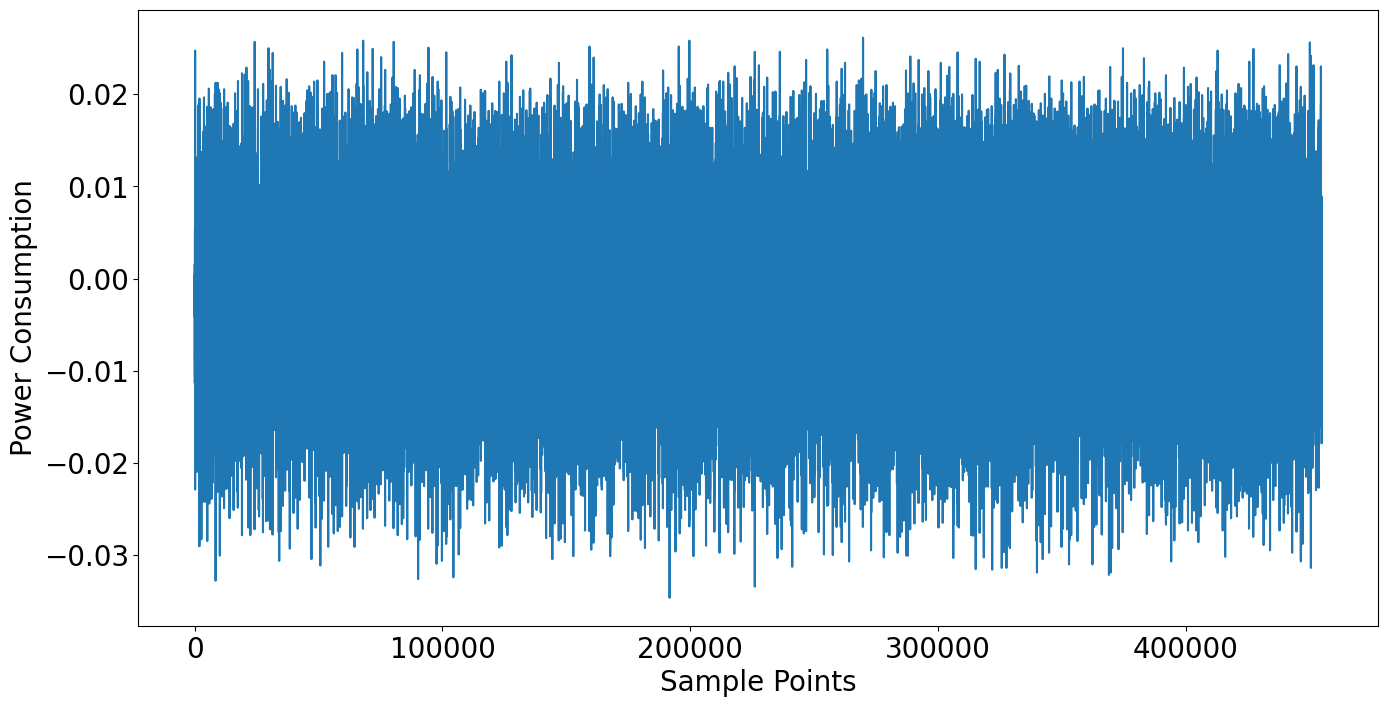

In [4]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Power Consumption', fontsize=20)
plt.plot(t[0])

In [5]:
# 使用 unpackbits 轉換成 bits，並指定 bitorder='little' 使 LSB 在前
bits = np.unpackbits(m.astype(np.uint8), axis=1, bitorder='little')  # 結果形狀: (2000, 256)
h = bits * 16

print(m.shape)
print(bits.shape)
print(h.shape)
print(m)
print(h)

(2000, 32)
(2000, 256)
(2000, 256)
[[116. 224.  11. ...   5. 141.  26.]
 [252.   7. 243. ...  58.  26.  43.]
 [ 22.  73.   3. ... 166.  16. 124.]
 ...
 [101.  94. 126. ... 250.  70.  99.]
 [  4.  99. 150. ... 140. 211. 153.]
 [211. 254. 103. ...  72. 192.  66.]]
[[ 0  0 16 ...  0  0  0]
 [ 0  0 16 ... 16  0  0]
 [ 0 16 16 ... 16 16  0]
 ...
 [16  0 16 ... 16 16  0]
 [ 0  0 16 ...  0  0 16]
 [16 16  0 ...  0 16  0]]


In [6]:
trace_length = t.shape[1]
print(trace_length)

455000


In [7]:
print("設定參數")
var = np.zeros((256, trace_length))    # 存16bytes分群後平均的變異數
avg = np.zeros((256, trace_length))    # 存16bytes分群後變異數的平均
SNR = np.zeros((256, trace_length))    # 存16bytes的SNR
avg_diff_HW = np.zeros((256, 2, trace_length)) # 存16bytes的九群的平均
var_diff_HW = np.zeros((256, 2, trace_length)) # 存16bytes的九群的變異數
count = np.zeros((256, 2), dtype=int)                    # 存 HW=0 ~ HW=8各有多少個

print("計算開始")
for b in range(256):                          # 16 bytes做16次
    t_sum = np.zeros((2, trace_length))      # 分成9群
    t2_sum = np.zeros((2, trace_length))
    avg_t = np.zeros((2, trace_length))
    avg2_t = np.zeros((2, trace_length))
    var_t = np.zeros((2, trace_length))
    
    for j in range(trace_num):               # 對每一行(每一byte)的不同 HW 做分群
        target = 1 if h[j, b] == 16 else 0   # 取得第j行(每一byte)所有HW，target會得到介於0到8的數值
        t_sum[target] += t[j]                # 將第j條波形的5000個樣本點加總到對應的 target index 那格中
        t2_sum[target] += t[j] ** 2
        count[b][target] += 1                # 九格分別代表 HW 0~8 共有多少條trace的
        
    prob = count[b] / trace_num              # 每一Byte"實際上"出現的機率
    
    for j in range(2):
        avg_t[j] = t_sum[j] / count[b][j]                     # 計算分群的平均
        var_t[j] = t2_sum[j] / count[b][j] - avg_t[j] ** 2    # 計算分群的變異數
    
    # 下面計算分群後平均的變異數; 平方的平均 - 平均的平方
    var[b] = sum((avg_t ** 2) * prob.reshape(2, 1)) - sum(avg_t * prob.reshape(2, 1)) ** 2
    avg[b] = sum(var_t * prob.reshape(2, 1)) # 計算分群變異數的平均
    
    avg_diff_HW[b] = avg_t
    var_diff_HW[b] = var_t
    print(b)
print("計算結束")

設定參數
計算開始
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
計算結束


In [8]:
for b in range(256):
    print("第{}Byte".format(b))
    for j in range(2):
        print("HW={}, 共有{:5d}條Traces.".format(j, count[b][j]))

第0Byte
HW=0, 共有  982條Traces.
HW=1, 共有 1018條Traces.
第1Byte
HW=0, 共有 1041條Traces.
HW=1, 共有  959條Traces.
第2Byte
HW=0, 共有  991條Traces.
HW=1, 共有 1009條Traces.
第3Byte
HW=0, 共有  995條Traces.
HW=1, 共有 1005條Traces.
第4Byte
HW=0, 共有 1022條Traces.
HW=1, 共有  978條Traces.
第5Byte
HW=0, 共有 1004條Traces.
HW=1, 共有  996條Traces.
第6Byte
HW=0, 共有 1001條Traces.
HW=1, 共有  999條Traces.
第7Byte
HW=0, 共有  981條Traces.
HW=1, 共有 1019條Traces.
第8Byte
HW=0, 共有 1023條Traces.
HW=1, 共有  977條Traces.
第9Byte
HW=0, 共有 1029條Traces.
HW=1, 共有  971條Traces.
第10Byte
HW=0, 共有 1024條Traces.
HW=1, 共有  976條Traces.
第11Byte
HW=0, 共有  991條Traces.
HW=1, 共有 1009條Traces.
第12Byte
HW=0, 共有 1017條Traces.
HW=1, 共有  983條Traces.
第13Byte
HW=0, 共有 1016條Traces.
HW=1, 共有  984條Traces.
第14Byte
HW=0, 共有 1035條Traces.
HW=1, 共有  965條Traces.
第15Byte
HW=0, 共有 1023條Traces.
HW=1, 共有  977條Traces.
第16Byte
HW=0, 共有 1011條Traces.
HW=1, 共有  989條Traces.
第17Byte
HW=0, 共有 1002條Traces.
HW=1, 共有  998條Traces.
第18Byte
HW=0, 共有 1014條Traces.
HW=1, 共有  986條Traces.
第19Byte
HW=0, 共有 1046條

In [9]:
print("分群後平均的變異數:")
print("Size=", var.shape, sep="")
for j in range(256):
    print("第 {:2} byte ".format(j), end="")
    print(var[j])

分群後平均的變異數:
Size=(256, 455000)
第  0 byte [6.71021878e-10 8.64266237e-10 1.74713435e-10 ... 3.85326093e-11
 7.43076081e-12 1.76968671e-11]
第  1 byte [3.74870778e-09 5.66643073e-09 2.44689921e-09 ... 3.00832112e-09
 9.02583505e-09 4.19259531e-09]
第  2 byte [5.39264483e-10 1.44868980e-09 1.12348011e-09 ... 1.70040759e-10
 4.51620869e-11 1.15549582e-10]
第  3 byte [8.69532685e-12 3.02615849e-11 2.56715980e-14 ... 2.81729076e-09
 7.51371464e-09 3.59473446e-09]
第  4 byte [6.93155962e-11 6.85659026e-10 7.75737298e-11 ... 1.36997448e-10
 2.84627180e-10 7.45908198e-13]
第  5 byte [4.61433553e-12 3.39942737e-10 1.90743397e-10 ... 1.59469713e-10
 1.57995090e-10 2.24284695e-09]
第  6 byte [6.27957977e-09 6.57262697e-09 1.92049760e-10 ... 2.41808789e-11
 4.39440666e-13 1.71663793e-10]
第  7 byte [7.69132987e-09 1.60793880e-09 6.83063011e-10 ... 7.82864967e-10
 7.86234120e-10 3.97390241e-09]
第  8 byte [5.25636011e-11 1.77482970e-12 1.06804770e-11 ... 5.18751160e-09
 5.76092675e-09 7.24294909e-10]
第  9 by

In [10]:
print("分群後變異數的平均:")
print("Size=", avg.shape, sep="")
for j in range(256):
    print("第 {:2} byte ".format(j), end="")
    print(avg[j])

分群後變異數的平均:
Size=(256, 455000)
第  0 byte [2.42464375e-06 3.03096950e-06 2.55092855e-06 ... 3.71253866e-06
 4.04082893e-06 5.13473405e-06]
第  1 byte [2.42156606e-06 3.02616734e-06 2.54865637e-06 ... 3.70956887e-06
 4.03181052e-06 5.13055915e-06]
第  2 byte [2.42477550e-06 3.03038508e-06 2.54997979e-06 ... 3.71240716e-06
 4.04079120e-06 5.13463620e-06]
第  3 byte [2.42530607e-06 3.03180351e-06 2.55110324e-06 ... 3.70975991e-06
 4.03332264e-06 5.13115702e-06]
第  4 byte [2.42524545e-06 3.03114811e-06 2.55102569e-06 ... 3.71244020e-06
 4.04055173e-06 5.13475100e-06]
第  5 byte [2.42531015e-06 3.03149382e-06 2.55091252e-06 ... 3.71241773e-06
 4.04067836e-06 5.13250890e-06]
第  6 byte [2.41903519e-06 3.02526114e-06 2.55091122e-06 ... 3.71255301e-06
 4.04083592e-06 5.13458009e-06]
第  7 byte [2.41762344e-06 3.03022583e-06 2.55042020e-06 ... 3.71179433e-06
 4.04005012e-06 5.13077785e-06]
第  8 byte [2.42526220e-06 3.03183199e-06 2.55109259e-06 ... 3.70738968e-06
 4.03507543e-06 5.13402745e-06]
第  9 by

In [11]:
SNR = var / avg
print("SNR:")
print("Size=", SNR.shape, sep="")
for j in range(256):
    print("第 {:2} byte ".format(j), end="")
    print(SNR[j])

SNR:
Size=(256, 455000)
第  0 byte [2.76750710e-04 2.85145145e-04 6.84901328e-05 ... 1.03790459e-05
 1.83891992e-06 3.44650121e-06]
第  1 byte [0.00154805 0.00187248 0.00096007 ... 0.00081096 0.00223866 0.00081718]
第  2 byte [2.22397695e-04 4.78054689e-04 4.40583928e-04 ... 4.58033702e-05
 1.11765455e-05 2.25039473e-05]
第  3 byte [3.58524928e-06 9.98138068e-06 1.00629397e-08 ... 7.59426710e-04
 1.86290939e-03 7.00569958e-04]
第  4 byte [2.85808581e-05 2.26204396e-04 3.04088391e-05 ... 3.69022638e-05
 7.04426522e-05 1.45266674e-07]
第  5 byte [1.90257544e-06 1.12137038e-04 7.47745740e-05 ... 4.29557567e-05
 3.91011300e-05 4.36988418e-04]
第  6 byte [2.59590261e-03 2.17258169e-03 7.52867283e-05 ... 6.51327504e-06
 1.08749941e-07 3.34328787e-05]
第  7 byte [0.00318136 0.00053063 0.00026782 ... 0.00021091 0.00019461 0.00077452]
第  8 byte [2.16733684e-05 5.85398433e-07 4.18662853e-06 ... 1.39923559e-03
 1.42771228e-03 1.41077335e-04]
第  9 byte [1.14852018e-04 3.39932309e-06 1.68070378e-05 ... 4.9

#### 找最大SNR

In [12]:
max_positions = np.where(SNR == np.max(SNR))
row, col = max_positions[0][0], max_positions[1][0]
print(f"最大值位置: ({row}, {col})")

最大值位置: (21, 38445)


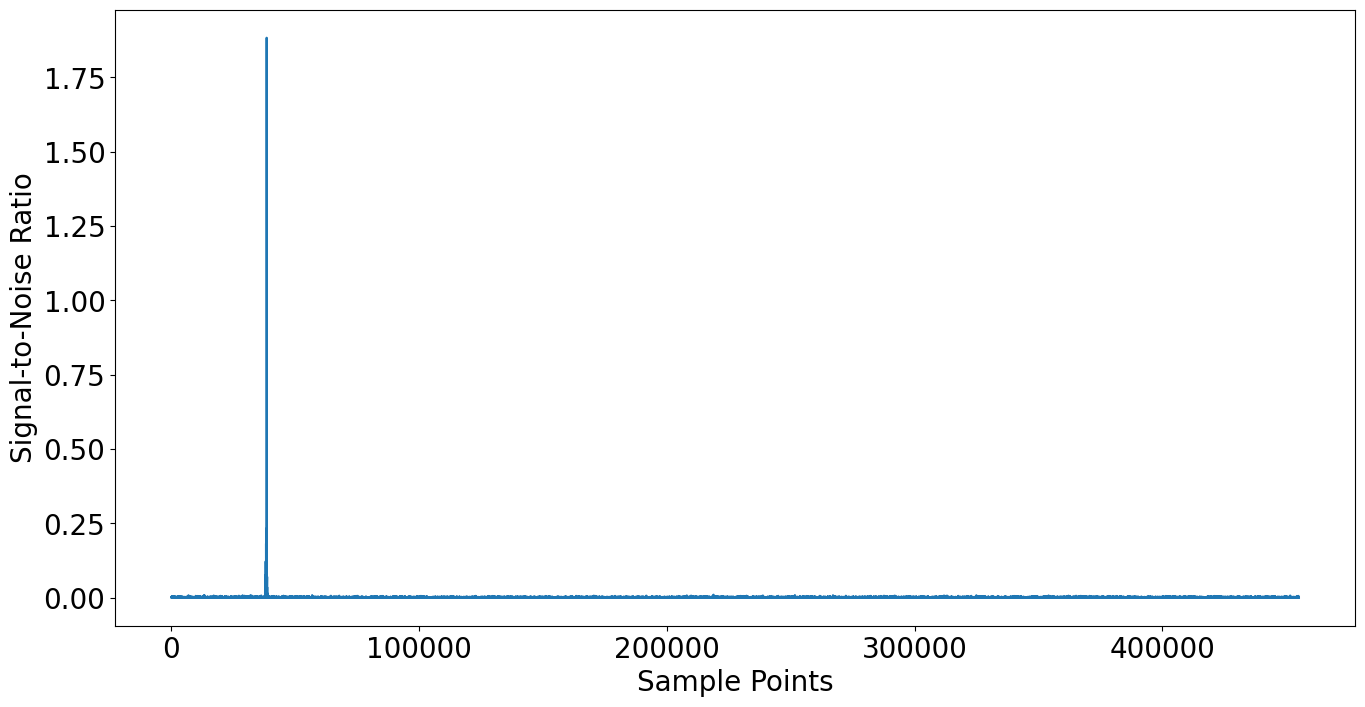

In [13]:
b = row
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=20)
plt.ylabel('Signal-to-Noise Ratio', fontsize=20)
plt.plot(SNR[b, :])

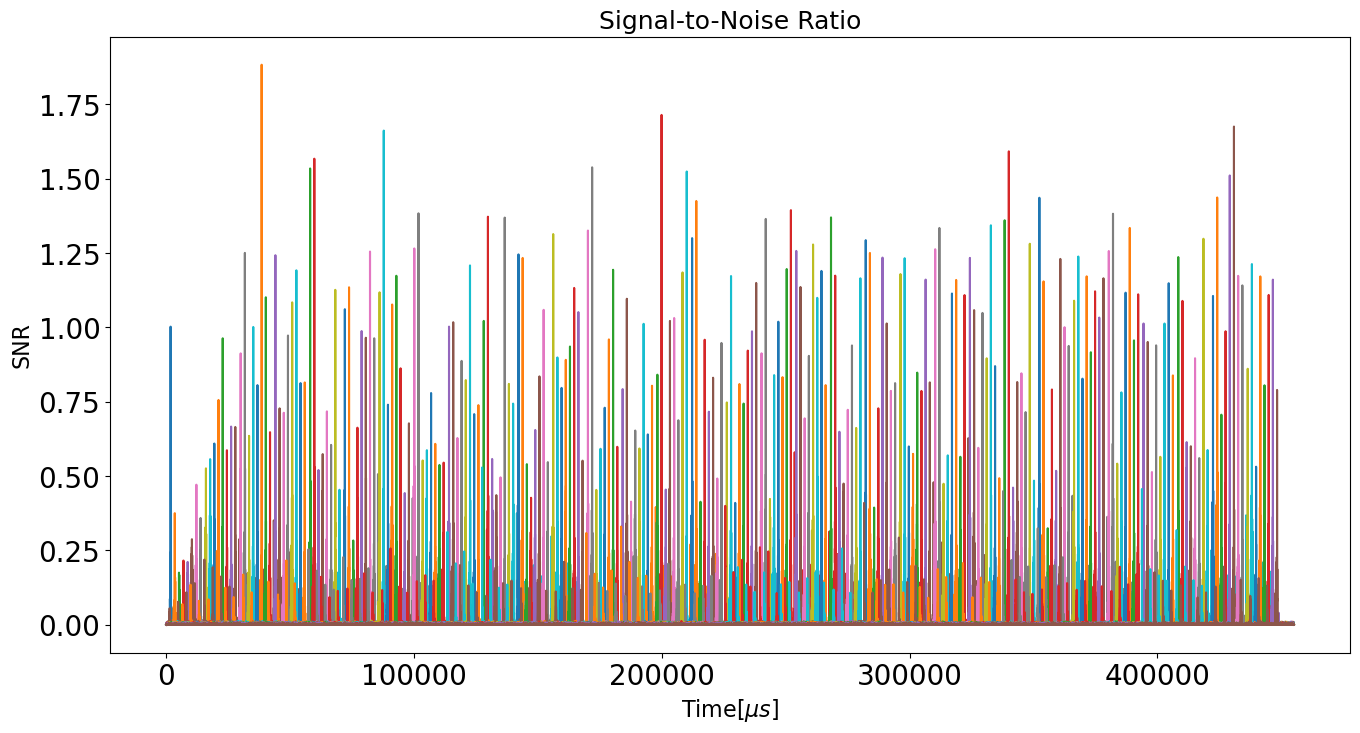

In [20]:
plt.figure(figsize=(16, 8))
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小

# plt.xlabel('Sample Points', fontsize=30)
plt.title('Signal-to-Noise Ratio', fontsize=18)

plt.xlabel(r'$\mathrm{Time} [\mu s]$' , fontsize=16)
# plt.ylabel('Signal-to-Noise Ratio', fontsize=16)
plt.ylabel('SNR', fontsize=16)
N = 455000
time = np.linspace(0, 910, N)  # 單位：µs

for b in range(256):
    value = max(SNR[b])
    index = np.argmax(SNR[b])
    # plt.text(index, value, '[{}, {}]'.format(index, value))
    plt.plot(SNR[b, :])

plt.savefig(f'figure/SNR/{platform}/{trace_num}/SNR.png', dpi=200, bbox_inches='tight')

In [15]:
# 對每一列 (axis=1) 找出最大值的索引
snr = np.argmax(SNR, axis=1)
# snr = np.sort(snr)        # 直接拿到「位置由小到大」的索引值

print("snr shape:", snr.shape)   # (256,)
print("snr:", snr)

snr shape: (256,)
snr: [  1694   3387   5079   6891   8583  10308  12106  13799  15964  17657
  19349  21044  22737  24430  26121  27813  29981  31675  33367  35060
  36753  38445  40138  41829  43998  45691  47383  49077  50770  52462
  54155  55848  58014  59707  61400  63093  64784  66478  68171  69862
  72030  73723  75417  77108  78801  80494  82187  83880  86047  87739
  89433  91125  92817  94510  96203  97897 100064 101756 103448 105140
 106834 108528 110218 111911 114079 115772 117464 119158 120851 122543
 124237 125929 128095 129788 131480 133175 134865 136559 138251 139944
 142112 143805 145497 147191 148882 150576 152269 153963 156128 157821
 159512 161207 162899 164592 166285 167978 170145 171838 173530 175223
 176915 178608 180301 181993 184161 185853 187546 189240 190933 192625
 194318 196010 198178 199870 201564 203255 204948 206641 208333 210027
 212194 213886 215579 217271 218963 220658 222356 224043 226210 227902
 229595 231288 232982 234673 236366 238059 240224 2419

In [16]:
# for b in range(256):
#     index = np.argmax(SNR[b])
#     center = index
#     window = 300
#     print(b, index)
#     x = np.arange(center-window, center+window+1)      # [671, 672, …, 771]
#     y = avg_diff_HW[b, :2, center-window:center+window+1]    # shape (2, 101)
#     plt.figure(figsize=(16, 8))
#     plt.rc('xtick', labelsize=30)   # x 軸刻度字體大小
#     plt.rc('ytick', labelsize=30)   # y 軸刻度字體大小
#     plt.xlabel('Sample Points', fontsize=30)
#     plt.ylabel('Power Consumption', fontsize=30)
#     plt.title("Bit{}".format(b), fontsize=30)
#     plt.plot(x, y[0], label='HW = 0')
#     plt.plot(x, y[1], label='HW = 16')
#     plt.legend(fontsize=10, loc='best')
#     # plt.grid(True)
#     plt.tight_layout()
#     # plt.savefig(f'figure/SNR/{platform}/{trace_num}/Bit{b}.png', dpi=200, bbox_inches='tight')

38445


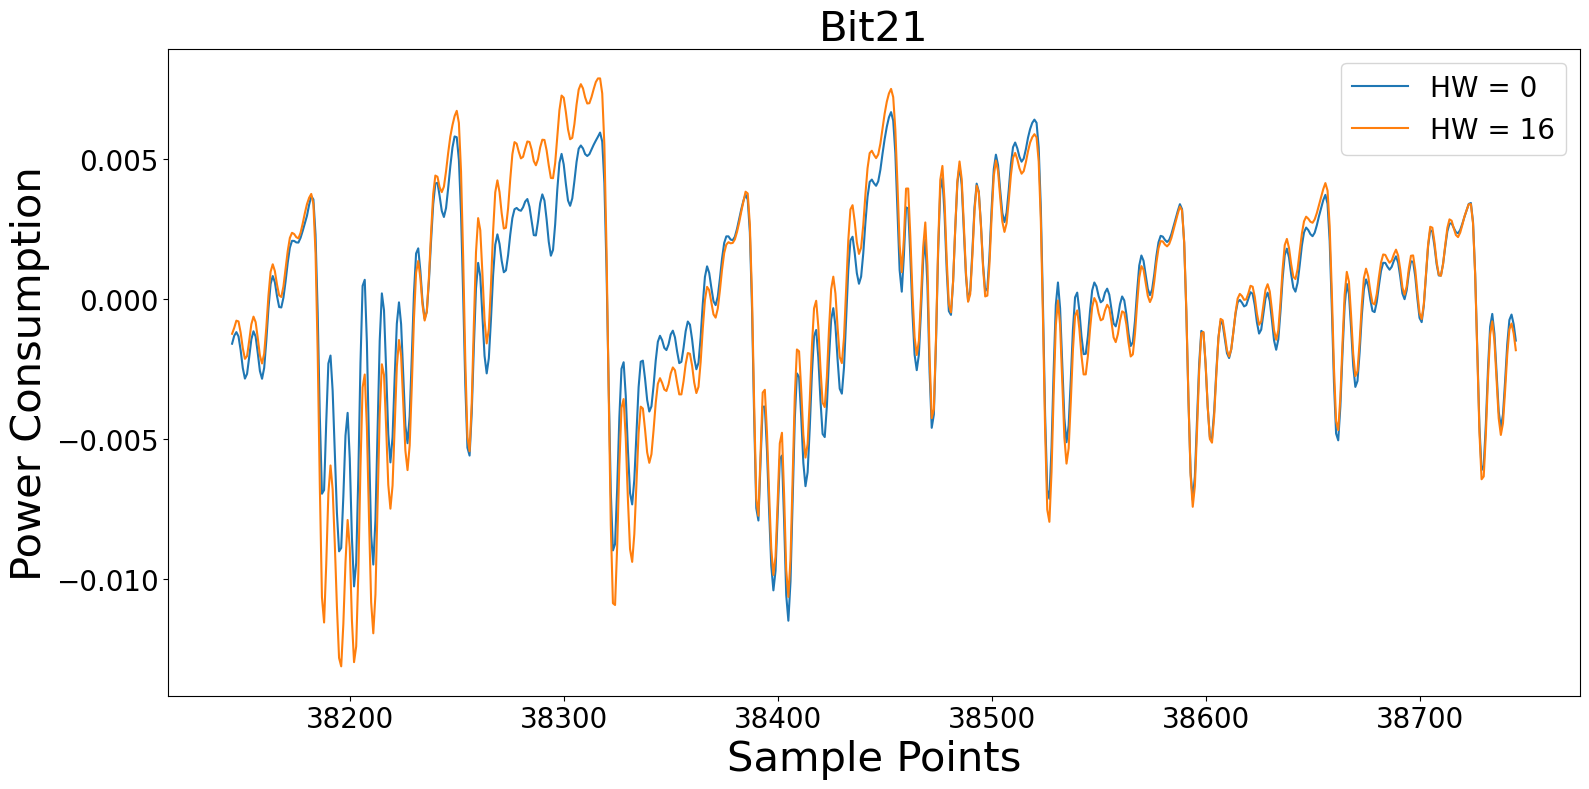

In [17]:
b = row
index = np.argmax(SNR[b])
center = index
window = 300
print(index)
x = np.arange(center-window, center+window+1)      # [671, 672, …, 771]
y = avg_diff_HW[b, :2, center-window:center+window+1]    # shape (2, 101)

plt.figure(figsize=(16, 8))
plt.plot(x, y[0], label='HW = 0')
plt.plot(x, y[1], label='HW = 16')
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)
plt.title(f'Bit{b}', fontsize=30)
plt.legend(fontsize=20, loc='best')
# plt.grid(True)
plt.tight_layout()
plt.savefig(f'figure/SNR/{platform}/{trace_num}/Bit{b}.png', dpi=200, bbox_inches='tight')
# plt.close()

38445


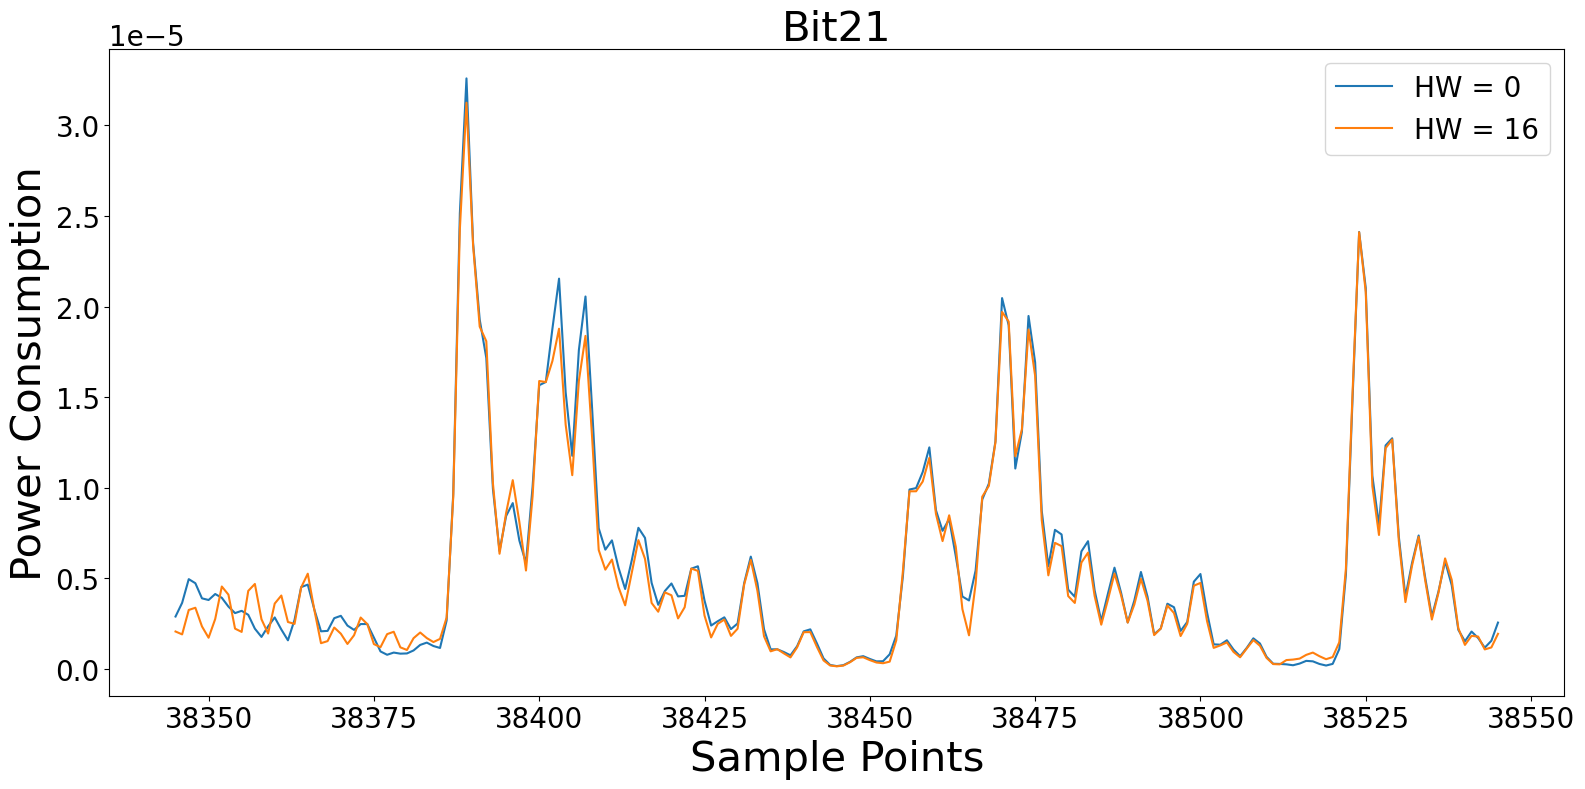

In [18]:
b = row
index = np.argmax(SNR[b])
center = index
window = 100
print(index)
x = np.arange(center-window, center+window+1)      # [671, 672, …, 771]
y = var_diff_HW[b, :2, center-window:center+window+1]    # shape (2, 101)

plt.figure(figsize=(16, 8))
plt.plot(x, y[0], label='HW = 0')
plt.plot(x, y[1], label='HW = 16')
plt.rc('xtick', labelsize=20)   # x 軸刻度字體大小
plt.rc('ytick', labelsize=20)   # y 軸刻度字體大小
plt.xlabel('Sample Points', fontsize=30)
plt.ylabel('Power Consumption', fontsize=30)
plt.title(f'Bit{b}', fontsize=30)
plt.legend(fontsize=20, loc='best')
# plt.grid(True)
plt.tight_layout()
# plt.savefig(f'figure/SNR/{platform}/{trace_num}/Bit{b}.png', dpi=200, bbox_inches='tight')
# plt.close()